# 02. Enrich empirical train

This notebook loads `empirical_train_mavg_out_v10.npz`, computes intrinsic observables such as $r$, $\sigma$, $s_+$, $s_\times$, $\omega$, $A$, and $\alpha$, and writes `empirical_train_mavg_out_v10b_enriched.npz`.

This enriched file is the shared input for the modeling and figure notebooks.


# Empirical diagnostics for the primary MEE train

This notebook is a lightweight, post-processing version of the empirical notebook.  It **does not rerun the expensive flow/cloud simulation**.  It loads

\[
(M,g)=(M^{(\mathrm{avg;out})},g^{(\mathrm{out})})
\]

from `empirical_train_mavg_out_v10.npz`, recomputes the empirical observables, and packages an enriched `.npz` file for the next SDE/generator-identification notebook.

Main corrections relative to earlier drafts:

1. only MEE and ellipsoid-averaged \(M\);
2. no \(M^{\rm reg}\), no Jeffery map, no lag analysis;
3. strain--vorticity is measured by the tensor-level diagnostic
\[
\chi(r)=\frac{\operatorname{Var}(\tilde\omega\mid r)}
{\operatorname{Var}(\tilde s_+\mid r)+\operatorname{Var}(\tilde s_\times\mid r)} ,
\]
whose incompressible isotropic 2D baseline is \(\chi=1\);
4. uncertainty estimates are seed/block-level, not naive sample SEM.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import ks_2samp

PI = np.pi
zeta = 1.0 / 3.0

infile = "/mnt/data/empirical_train_mavg_out_v10.npz"
data = np.load(infile)

times = data["times"]
M = data["M"]
g = data["g"]
r_edges = data["r_edges"]
r_centers = data["r_centers"]
bin_idx_flat = data["bin_idx"]

n_seeds, n_rec, _, _ = M.shape
dt = float(times[1] - times[0])

print("Loaded:", infile)
print("M shape:", M.shape, "g shape:", g.shape)
print("dt:", dt, "n_seeds:", n_seeds, "n_rec:", n_rec)


Loaded: /mnt/data/empirical_train_mavg_out_v10.npz
M shape: (12, 1501, 2, 2) g shape: (12, 1501, 2, 2)
dt: 0.01 n_seeds: 12 n_rec: 1501


## 1. Observables

We use the convention

\[
M=\begin{pmatrix}
s_+ & s_\times+\omega\\
s_\times-\omega & -s_+
\end{pmatrix}.
\]

The reduced quadratic norm is

\[
|M|_{\rm red}^2=s_+^2+s_\times^2+\omega^2,
\]

while the Frobenius norm is

\[
\|M\|_F^2=2|M|_{\rm red}^2.
\]

Slopes are identical, but labels must not mix these conventions.


In [2]:
def compute_observables(M, g):
    n_seeds, n_rec, _, _ = M.shape
    shape = (n_seeds, n_rec)

    s_plus  = 0.5 * (M[:, :, 0, 0] - M[:, :, 1, 1])
    s_cross = 0.5 * (M[:, :, 0, 1] + M[:, :, 1, 0])
    omega   = 0.5 * (M[:, :, 0, 1] - M[:, :, 1, 0])

    v = np.zeros(shape)
    sigma = np.zeros(shape)
    theta_g = np.zeros(shape)
    theta_s = np.zeros(shape)

    for a in range(n_seeds):
        for t in range(n_rec):
            G = 0.5 * (g[a, t] + g[a, t].T)
            vals, vecs = np.linalg.eigh(G)
            vals = np.maximum(vals, 1e-14)
            order = np.argsort(vals)[::-1]
            vals = vals[order]
            vecs = vecs[:, order]
            v[a, t] = 0.25 * np.log(vals[0] * vals[1])
            sigma[a, t] = 0.5 * np.log(vals[0] / vals[1])
            theta_g[a, t] = np.arctan2(vecs[1, 0], vecs[0, 0]) % PI

            S = 0.5 * (M[a, t] + M[a, t].T)
            evals, evecs = np.linalg.eigh(S)
            j = np.argmax(evals)
            theta_s[a, t] = np.arctan2(evecs[1, j], evecs[0, j]) % PI

    r = np.exp(v)
    return dict(s_plus=s_plus, s_cross=s_cross, omega=omega,
                v=v, sigma=sigma, theta_g=theta_g, theta_s=theta_s, r=r)

obs = compute_observables(M, g)
bin_idx = np.digitize(obs["r"].ravel(), r_edges) - 1
valid = (bin_idx >= 0) & (bin_idx < len(r_centers))

print("sigma range:", float(np.nanmin(obs["sigma"])), float(np.nanmax(obs["sigma"])))
print("r range:", float(np.nanmin(obs["r"])), float(np.nanmax(obs["r"])))
print("Valid binned samples:", int(valid.sum()), "of", bin_idx.size)
print("\nBin populations:")
for k, rc in enumerate(r_centers):
    print(f"  {k:2d}  r={rc:7.3f}  n={(bin_idx == k).sum():6d}")


sigma range: 0.0020355506816782535 2.256825154119682
r range: 0.2060030009767877 2.3104696955516695
Valid binned samples: 16487 of 18012

Bin populations:
   0  r=  0.314  n=  1536
   1  r=  0.419  n=  1705
   2  r=  0.559  n=  1981
   3  r=  0.746  n=  3014
   4  r=  0.994  n=  3819
   5  r=  1.326  n=  3081
   6  r=  1.768  n=  1351


## 2. Seed-level helper functions

The seed-level estimates avoid pretending that all time samples are independent.
They are still approximate because each seed trajectory is temporally correlated, but they are more honest than naive pointwise SEMs.


In [3]:
def per_seed_bin_values(x, reducer=np.nanmean):
    # Return array [n_seeds, n_bins] of a statistic for x in each seed/bin.
    x = np.asarray(x)
    n_bins = len(r_centers)
    out = np.full((n_seeds, n_bins), np.nan)
    b2 = bin_idx.reshape(n_seeds, n_rec)
    for s in range(n_seeds):
        for k in range(n_bins):
            vals = x[s][b2[s] == k]
            if vals.size:
                out[s, k] = reducer(vals)
    return out

def seed_mean_sem(seed_vals):
    mean = np.nanmean(seed_vals, axis=0)
    n_eff = np.sum(np.isfinite(seed_vals), axis=0)
    sem = np.nanstd(seed_vals, axis=0, ddof=1) / np.sqrt(np.maximum(n_eff, 1))
    return mean, sem

def angle_diff_mod_pi(a, b):
    return (a - b + PI/2) % PI - PI/2


## 3. Shape saturation

Interpretation target: **bounded \(O(1)\) MEE aspect ratio**, not exact scale-invariant distributional saturation.


bin       r     mean  seed_SE      q25      q50      q75
  0   0.314    1.032    0.068    0.800    0.932    1.090
  1   0.419    1.084    0.078    0.846    1.024    1.372
  2   0.559    1.117    0.128    0.717    1.028    1.340
  3   0.746    1.044    0.143    0.517    0.791    1.208
  4   0.994    1.035    0.123    0.603    0.957    1.218
  5   1.326    0.831    0.119    0.495    0.734    1.154
  6   1.768    0.835    0.119    0.609    0.726    0.986



Pairwise KS distances for P(sigma | r):
[[0.    0.214 0.211 0.259 0.136 0.349 0.321]
 [0.214 0.    0.115 0.302 0.169 0.409 0.373]
 [0.211 0.115 0.    0.202 0.109 0.323 0.29 ]
 [0.259 0.302 0.202 0.    0.162 0.123 0.141]
 [0.136 0.169 0.109 0.162 0.    0.274 0.251]
 [0.349 0.409 0.323 0.123 0.274 0.    0.154]
 [0.321 0.373 0.29  0.141 0.251 0.154 0.   ]]


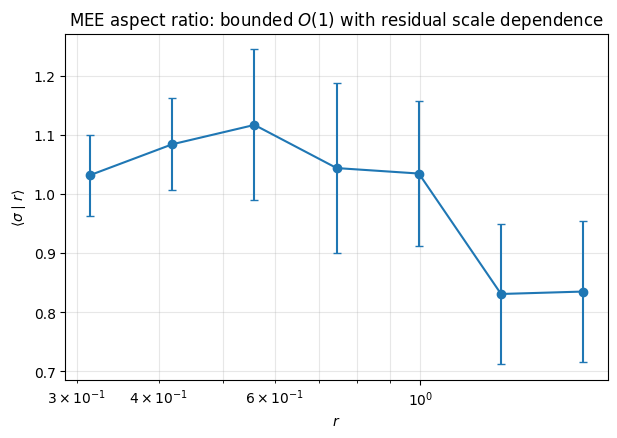

In [4]:
sig_seed = per_seed_bin_values(obs["sigma"], np.nanmean)
sig_mean, sig_sem_seed = seed_mean_sem(sig_seed)

q25 = np.full(len(r_centers), np.nan)
q50 = np.full(len(r_centers), np.nan)
q75 = np.full(len(r_centers), np.nan)
sig_flat = obs["sigma"].ravel()
for k in range(len(r_centers)):
    vals = sig_flat[bin_idx == k]
    if vals.size:
        q25[k], q50[k], q75[k] = np.nanpercentile(vals, [25, 50, 75])

print(f"{'bin':>3} {'r':>7} {'mean':>8} {'seed_SE':>8} {'q25':>8} {'q50':>8} {'q75':>8}")
for k in range(len(r_centers)):
    print(f"{k:3d} {r_centers[k]:7.3f} {sig_mean[k]:8.3f} {sig_sem_seed[k]:8.3f} {q25[k]:8.3f} {q50[k]:8.3f} {q75[k]:8.3f}")

ks = np.zeros((len(r_centers), len(r_centers)))
for i in range(len(r_centers)):
    xi = sig_flat[bin_idx == i]
    for j in range(len(r_centers)):
        xj = sig_flat[bin_idx == j]
        ks[i, j] = ks_2samp(xi, xj).statistic if xi.size and xj.size else np.nan

print("\nPairwise KS distances for P(sigma | r):")
print(np.round(ks, 3))

plt.figure(figsize=(7, 4.5))
plt.errorbar(r_centers, sig_mean, yerr=sig_sem_seed, fmt='o-', capsize=3)
plt.xscale('log')
plt.xlabel(r'$r$')
plt.ylabel(r'$\langle\sigma\mid r\rangle$')
plt.title(r'MEE aspect ratio: bounded $O(1)$ with residual scale dependence')
plt.grid(True, which='both', alpha=0.3)
plt.show()


## 4. Corrected strain--vorticity balance

The component-level factor of two is the 2D incompressible baseline.  The diagnostic below tests the tensor-level balance \(\chi=1\).


bin       r     var_sp     var_sx     var_om      chi   chi_SE   comp_ratio
  0   0.314    0.02981    0.02301    0.05178    1.104    0.177        2.209
  1   0.419    0.02429    0.02442    0.05177    1.175    0.282        2.349
  2   0.559    0.02412    0.01834    0.03547    0.925    0.156        1.851
  3   0.746    0.01839     0.0248    0.04763    1.129    0.200        2.259
  4   0.994    0.02379    0.02027    0.04156    0.946    0.137        1.892
  5   1.326    0.01055     0.0211    0.03973    1.314    0.159        2.629
  6   1.768     0.0057    0.01034    0.01853    1.262    0.316        2.524


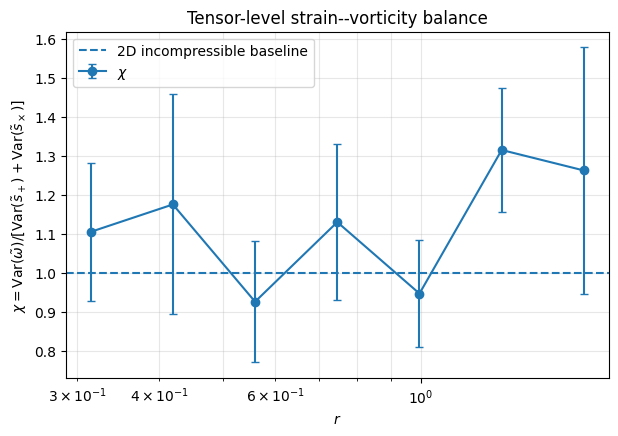

In [5]:
rfac = obs["r"] ** (1.0 - zeta)
sp_t = obs["s_plus"] * rfac
sx_t = obs["s_cross"] * rfac
om_t = obs["omega"] * rfac

def var_reducer(x):
    return np.nanvar(x, ddof=1) if len(x) > 1 else np.nan

sp_var_seed = per_seed_bin_values(sp_t, var_reducer)
sx_var_seed = per_seed_bin_values(sx_t, var_reducer)
om_var_seed = per_seed_bin_values(om_t, var_reducer)

sp_var, sp_var_se = seed_mean_sem(sp_var_seed)
sx_var, sx_var_se = seed_mean_sem(sx_var_seed)
om_var, om_var_se = seed_mean_sem(om_var_seed)

chi_seed = om_var_seed / (sp_var_seed + sx_var_seed)
comp_seed = 2.0 * om_var_seed / (sp_var_seed + sx_var_seed)
chi, chi_se = seed_mean_sem(chi_seed)
comp_ratio, comp_ratio_se = seed_mean_sem(comp_seed)

print(f"{'bin':>3} {'r':>7} {'var_sp':>10} {'var_sx':>10} {'var_om':>10} {'chi':>8} {'chi_SE':>8} {'comp_ratio':>12}")
for k in range(len(r_centers)):
    print(f"{k:3d} {r_centers[k]:7.3f} {sp_var[k]:10.4g} {sx_var[k]:10.4g} {om_var[k]:10.4g} {chi[k]:8.3f} {chi_se[k]:8.3f} {comp_ratio[k]:12.3f}")

plt.figure(figsize=(7, 4.5))
plt.errorbar(r_centers, chi, yerr=chi_se, fmt='o-', capsize=3, label=r'$\chi$')
plt.axhline(1.0, linestyle='--', label='2D incompressible baseline')
plt.xscale('log')
plt.xlabel(r'$r$')
plt.ylabel(r'$\chi=\mathrm{Var}(\tilde\omega)/[\mathrm{Var}(\tilde s_+)+\mathrm{Var}(\tilde s_\times)]$')
plt.title('Tensor-level strain--vorticity balance')
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.show()


## 5. \(M\)-scaling

The slope is fit for the reduced norm \( |M|_{\rm red}^2=s_+^2+s_\times^2+\omega^2 \).  The Frobenius norm differs by a factor of two and has the same slope.


MEE + ellipsoid-averaged M: slope for |M|_red^2 = -1.990 ± 0.131
Dimensional K41 reference: -1.3333333333333333
Frobenius norm = 2 |M|_red^2, same slope.


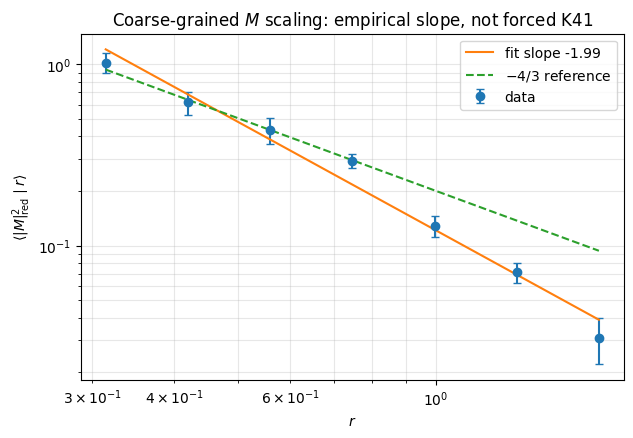

In [6]:
M2_red = obs["s_plus"]**2 + obs["s_cross"]**2 + obs["omega"]**2
M2_seed = per_seed_bin_values(M2_red, np.nanmean)
M2_mean, M2_se = seed_mean_sem(M2_seed)

valid_slope = np.isfinite(M2_mean) & (M2_mean > 0)
slope, intercept, r_value, p_value, slope_se = stats.linregress(np.log(r_centers[valid_slope]), np.log(M2_mean[valid_slope]))

print(f"MEE + ellipsoid-averaged M: slope for |M|_red^2 = {slope:.3f} ± {slope_se:.3f}")
print("Dimensional K41 reference:", -4/3)
print("Frobenius norm = 2 |M|_red^2, same slope.")

plt.figure(figsize=(7, 4.5))
plt.errorbar(r_centers, M2_mean, yerr=M2_se, fmt='o', capsize=3, label='data')
rr = np.geomspace(r_centers.min(), r_centers.max(), 200)
plt.plot(rr, np.exp(intercept) * rr**slope, label=f'fit slope {slope:.2f}')
plt.plot(rr, M2_mean[2] * (rr / r_centers[2])**(-4/3), '--', label=r'$-4/3$ reference')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$r$')
plt.ylabel(r'$\langle |M|_{\rm red}^2\mid r\rangle$')
plt.title(r'Coarse-grained $M$ scaling: empirical slope, not forced K41')
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.show()


## 6. Component non-Gaussianity

These are empirical constraints for later stochastic modeling, not fitting targets in this notebook.


In [7]:
def skew_reducer(x):
    return stats.skew(x, bias=False, nan_policy='omit') if len(x) > 5 else np.nan

def kurt_reducer(x):
    return stats.kurtosis(x, fisher=True, bias=False, nan_policy='omit') if len(x) > 5 else np.nan

components = {'s+': sp_t, 'sx': sx_t, 'omega': om_t}
print("Skewness by bin:")
for name, arr in components.items():
    vals, se = seed_mean_sem(per_seed_bin_values(arr, skew_reducer))
    print(name, np.round(vals, 3), "SE", np.round(se, 3))

print("\nExcess kurtosis by bin:")
for name, arr in components.items():
    vals, se = seed_mean_sem(per_seed_bin_values(arr, kurt_reducer))
    print(name, np.round(vals, 3), "SE", np.round(se, 3))


Skewness by bin:
s+ [-0.059 -0.082  0.212 -0.03  -0.021  0.097 -0.138] SE [0.177 0.132 0.12  0.094 0.076 0.14  0.114]
sx [ 0.184 -0.219 -0.229  0.197  0.096 -0.196  0.037] SE [0.158 0.141 0.118 0.117 0.106 0.119 0.061]
omega [ 0.155  0.001 -0.039 -0.002  0.021  0.31  -0.102] SE [0.11  0.164 0.131 0.086 0.09  0.097 0.098]

Excess kurtosis by bin:
s+ [-0.353 -0.181 -0.411 -0.571 -0.722 -0.279 -0.508] SE [0.274 0.169 0.092 0.119 0.139 0.205 0.356]
sx [-0.255 -0.48  -0.369 -0.442 -0.46  -0.519 -0.957] SE [0.216 0.191 0.102 0.136 0.117 0.16  0.197]
omega [-0.494 -0.14  -0.452 -0.777 -0.293 -0.585 -0.58 ] SE [0.132 0.275 0.137 0.09  0.214 0.102 0.193]


## 7. Alignment and lifted shape

Useful empirical constraints for the next generator-identification notebook.


bin       r     <cos 2(theta_S-theta_g)>       SE
  0   0.314                        0.427    0.085
  1   0.419                        0.291    0.113
  2   0.559                        0.399    0.087
  3   0.746                        0.288    0.094
  4   0.994                        0.189    0.087
  5   1.326                        0.175    0.107
  6   1.768                        0.023    0.181


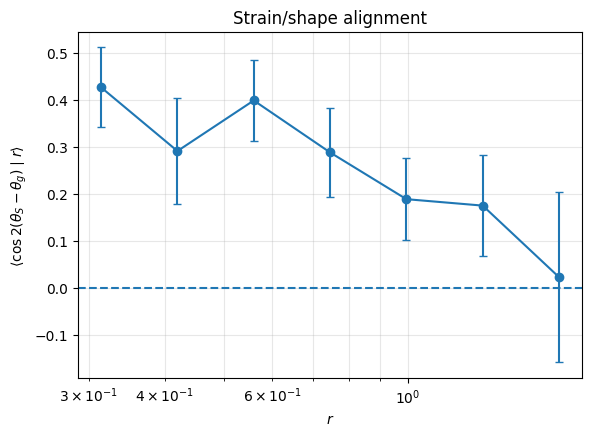

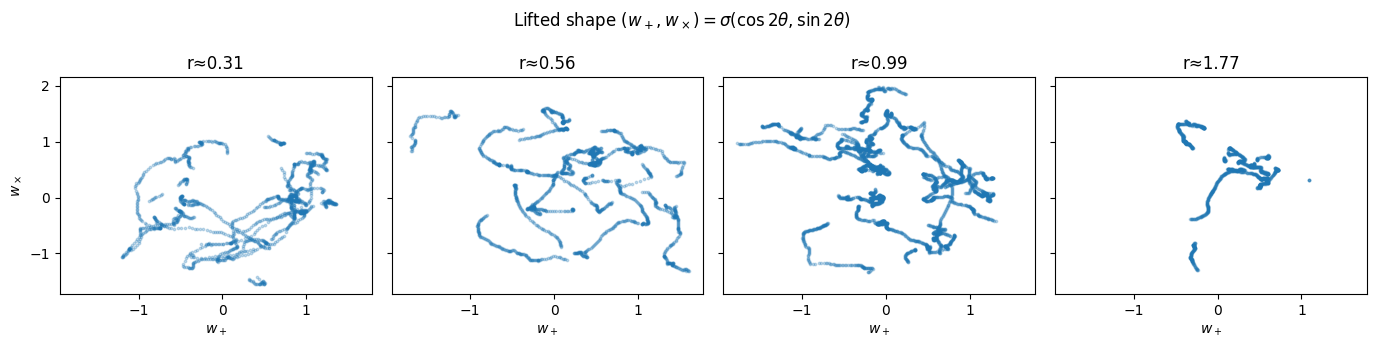

In [8]:
theta_diff = angle_diff_mod_pi(obs["theta_s"], obs["theta_g"])
align = np.cos(2.0 * theta_diff)

align_seed = per_seed_bin_values(align, np.nanmean)
align_mean, align_se = seed_mean_sem(align_seed)

print(f"{'bin':>3} {'r':>7} {'<cos 2(theta_S-theta_g)>':>28} {'SE':>8}")
for k in range(len(r_centers)):
    print(f"{k:3d} {r_centers[k]:7.3f} {align_mean[k]:28.3f} {align_se[k]:8.3f}")

plt.figure(figsize=(6.5, 4.5))
plt.errorbar(r_centers, align_mean, yerr=align_se, fmt='o-', capsize=3)
plt.axhline(0.0, linestyle='--')
plt.xscale('log')
plt.xlabel(r'$r$')
plt.ylabel(r'$\langle \cos 2(\theta_S-\theta_g)\mid r\rangle$')
plt.title('Strain/shape alignment')
plt.grid(True, which='both', alpha=0.3)
plt.show()

w_plus = obs["sigma"] * np.cos(2.0 * obs["theta_g"])
w_cross = obs["sigma"] * np.sin(2.0 * obs["theta_g"])

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5), sharex=True, sharey=True)
plot_bins = [0, 2, 4, 6]
for ax, k in zip(axes, plot_bins):
    mask = (bin_idx.reshape(n_seeds, n_rec) == k)
    ax.scatter(w_plus[mask], w_cross[mask], s=3, alpha=0.25)
    ax.set_title(f"r≈{r_centers[k]:.2f}")
    ax.set_xlabel(r"$w_+$")
axes[0].set_ylabel(r"$w_\times$")
plt.suptitle(r"Lifted shape $(w_+,w_\times)=\sigma(\cos 2\theta,\sin 2\theta)$")
plt.tight_layout()
plt.show()


## 8. Save enriched empirical file

The next notebook should load this file and proceed directly to conditional generator identification and SDE calibration.


In [9]:
outfile = "/mnt/data/empirical_train_mavg_out_v10b_enriched.npz"
np.savez_compressed(
    outfile,
    times=times,
    M=M,
    g=g,
    r_edges=r_edges,
    r_centers=r_centers,
    bin_idx=bin_idx,
    s_plus=obs["s_plus"],
    s_cross=obs["s_cross"],
    omega=obs["omega"],
    v=obs["v"],
    sigma=obs["sigma"],
    theta_g=obs["theta_g"],
    theta_s=obs["theta_s"],
    r=obs["r"],
    sigma_mean=sig_mean,
    sigma_sem_seed=sig_sem_seed,
    chi=chi,
    chi_sem_seed=chi_se,
    M2_red_mean=M2_mean,
    M2_red_sem_seed=M2_se,
    M2_red_slope=slope,
    M2_red_slope_se=slope_se,
    alignment_mean=align_mean,
    alignment_sem_seed=align_se,
)
print("Saved enriched empirical file:", outfile)


Saved enriched empirical file: /mnt/data/empirical_train_mavg_out_v10b_enriched.npz


## 9. Summary for the notes

1. The primary train \((M,g)=(M^{(\mathrm{avg;out})},g^{(\mathrm{out})})\) is internally consistent and ready for reduced modeling.
2. The MEE aspect ratio remains \(O(1)\), but the present run shows residual scale dependence; it is safer to state bounded/plateau-like behavior rather than exact distributional saturation.
3. The corrected tensor-level strain--vorticity diagnostic \(\chi\) fluctuates around the incompressible baseline \(\chi=1\), with finite-bin deviations.  The old factor-of-two component statement should not be presented as anisotropy.
4. The measured \(M\)-scaling is substantially steeper than \(-4/3\) in this run.  This should be treated as an empirical outcome of the ellipsoid-averaged, finite-range, Bessel-filtered coarse graining, not forced into K41 agreement.
5. The next notebook should start from the enriched `.npz` and estimate the conditional generator: OU/VAR statistics for \(M\), residual drift for \(g\), and then forward-simulate the calibrated baseline SDE.
